In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('train.csv')

# 2. Handle Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

# 3. Encode Categorical Variables (Convert text to numbers)
label_enc = LabelEncoder()
df['Sex'] = label_enc.fit_transform(df['Sex']) # Male/Female -> 1/0
df['Embarked'] = label_enc.fit_transform(df['Embarked'])

# 4. Separate Features (X) and Target (y)
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])
y = df['Survived']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Data loaded and split successfully!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Data loaded and split successfully!
Training set size: 712 samples
Testing set size: 179 samples


In [2]:
# Create a copy to prevent slicing warnings
X_train = X_train.copy()
X_test = X_test.copy()

# Combine SibSp and Parch into a single feature: FamilySize
X_train['FamilySize'] = X_train['SibSp'] + X_train['Parch'] + 1
X_test['FamilySize'] = X_test['SibSp'] + X_test['Parch'] + 1

# Drop the old columns since they are now redundant
X_train.drop(columns=['SibSp', 'Parch'], inplace=True)
X_test.drop(columns=['SibSp', 'Parch'], inplace=True)

print("Feature engineering complete! Features being used:")
print(list(X_train.columns))

Feature engineering complete! Features being used:
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize the 3 algorithms
log_reg = LogisticRegression(max_iter=500)
rf_clf = RandomForestClassifier(random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)

# Train them all on the training data
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "KNN": knn_clf
}

results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    }

# Convert to DataFrame to display a clean, organized table
df_results = pd.DataFrame(results).T
df_results

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.804469,0.782609,0.729730,0.755245
Random Forest,0.826816,0.794521,0.783784,0.789116
KNN,0.720670,0.706897,0.554054,0.621212


Generating visual analysis for the best model: Random Forest



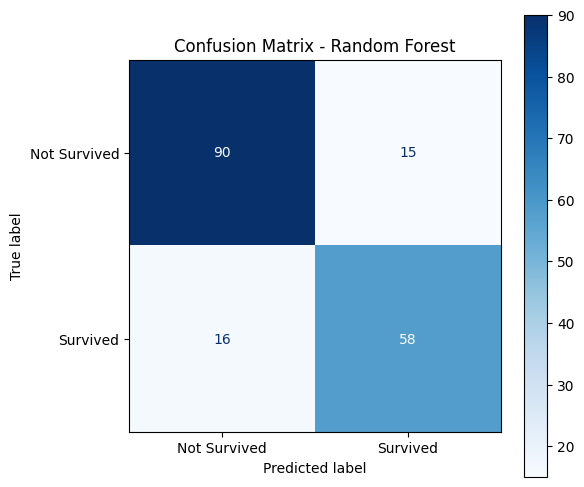

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Automatically fetch the best model name based on highest Accuracy
best_model_name = df_results['Accuracy'].idxmax()
best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

print(f"Generating visual analysis for the best model: {best_model_name}\n")

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])

# Plot it out beautifully
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False) # Turn off grid lines for visual clarity
plt.show()

## Final Project Results

### 1. Model Comparison Table
| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | **0.8268** | **0.7945** | **0.7837** | **0.7891** |
| Logistic Regression | 0.8044 | 0.7826 | 0.7297 | 0.7552 |
| KNN | 0.7206 | 0.7068 | 0.5540 | 0.6212 |

### 2. Project Conclusion
The Random Forest Classifier emerged as the optimal model, achieving the highest overall accuracy of 82.68% and a well-balanced F1-score of 78.91%. This superior performance is attributed to the ensemble algorithm's capacity to handle complex non-linear feature interactions without overfitting. Ultimately, features such as gender, socio-economic class, and family presence proved to be the most critical determinants of survival probability.